# Session 13 - Decision Tree

Decision tree:

A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes. It works like a flowchart that helps in making step-by-step decisions, where:

Internal nodes represent attribute tests

Branches represent attribute values

Leaf nodes represent final decisions or predictions.

Decision trees are widely used due to their interpretability, flexibility and low preprocessing needs


How Does a Decision Tree Work:

A decision tree splits the dataset based on feature values to create pure subsets ideally all items in a group belong to the same class. Each leaf node represents the final output, which can be a class label (in classification) or a continuous value (in regression).


point: Decision trees are UNSYMMETRICAL (unbalanced) in almost all real-world cases. and always split into two if split

point : different branches can (and often do) use completely different features at the same depth or anywhere in the tree.

point: no scaling needed

point: decision trees are fundamentally feature selection tools that identify which features best separate the data; classification and regression are just natural extensions, but you can use the tree only to find important features and thresholds, then discard the tree itself or feed the reduced features into other models.


 We have two popular attribute selection measures used:

1. Information Gain
Information Gain tells us how useful a question (or feature) is for splitting data into groups. It measures how much the uncertainty decreases after the split. A good question will create clearer groups and the feature with the highest Information Gain is chosen to make the decision.

Information Gain = How much entropy (uncertainty) we remove by splitting

Entropy = How "mixed up" or "impure" your data is

Half-half	5 apples, 5 oranges	High (1.0)	Maximum uncertainty

Entropy = -[ (p_a × log₂(p_a)) + (p_b × log₂(p_b)) ]     # Where p = proportion (fraction)

Gain(S, A) = Entropy(S) - Σ [ |Sv|/|S| × Entropy(Sv) ]  # higer better improvement and purity

S	Dataset before split	8 items (3a, 5b)

A	The feature we split on	"Age > 30?"

Sv	Each group after split	Left group: 4 items, Right group: 4 items

2. Gini Index
Gini Index is a metric to measure how often a randomly chosen element would be incorrectly identified. It means an attribute with a lower Gini index should be preferred. Sklearn supports “Gini” criteria for Gini Index and by default it takes “gini” value.

For example if we have a group of people where all bought the product (100% "Yes") the Gini Index is 0 indicate perfect purity. But if the group has an equal mix of "Yes" and "No" the Gini Index would be 0.5 show high impurity or uncertainty. Formula for Gini Index is given by :

Formula: Gini = 1 - Σ(p_i²)

A lower Gini Index indicates a more homogeneous or pure distribution while a higher Gini Index indicates a more heterogeneous or impure distribution.

Gini Index is used to evaluate the quality of a split by measuring the difference between the impurity of the parent node and the weighted impurity of the child nodes.

Compared to other impurity measures like entropy, the Gini Index is faster to compute and more sensitive to changes in class probabilities.

one disadvantage of the Gini Index is that it tends to favour splits that create equally sized child nodes, even if they are not optimal for classification accuracy.

In practice the choice between using the Gini Index or other impurity measures depends on the specific problem and dataset and requires experimentation and tuning.




Entropy measures how mixed your data is (0 = pure, 1 = totally mixed). Information Gain measures how much a split reduces entropy — pick the feature with highest gain. Gini is a faster alternative to entropy that gives similar results.



whole in my words :

 the whole process is : all feature sorted then se select some threshould for eacg feature for example mean of between two soretd valuse as yhreshould for each features then we do this in all features now we split root nodes to two nodes and in all case (each features compare other features,each threshoul ofeach fearure with another threshould of same fetaure) then caculate gini and find best ginis so we can select which threshould for each feature is good and chose that and also we finde amoung all features which is better than other to gou top now we can draw a tree decision with order


-------------------

# ================================================================================
# DECISION TREE HYPERPARAMETERS - COMPLETE REFERENCE
# ================================================================================

"""
TYPES OF HYPERPARAMETERS IN DECISION TREE
===============================================================================

1. CRITERION (Split Quality Measure)
-------------------------------------
    - 'gini'      : Gini impurity (default) - measures probability distribution
    - 'entropy'   : Information gain - measures uncertainty reduction

    Usage:
        clf = DecisionTreeClassifier(criterion='gini')
        clf = DecisionTreeClassifier(criterion='entropy')


2. MAX_DEPTH (Maximum Tree Depth)
-----------------------------------
    - Controls how deep the tree can grow
    - Deeper trees capture more patterns but risk overfitting
    - Shallower trees may underfit

    Values:
        - Integer (e.g., 3, 5, 10) : exact depth limit
        - None : no limit (tree grows until pure or min_samples conditions)

    Usage:
        clf = DecisionTreeClassifier(max_depth=5)
        clf = DecisionTreeClassifier(max_depth=None)


3. MIN_SAMPLES_SPLIT (Minimum Samples to Split)
------------------------------------------------
    - Minimum number of samples required to split an internal node
    - If node has fewer samples, it becomes a leaf

    Values:
        - Integer : exact number (e.g., 10 means need ≥10 samples to split)
        - Float   : percentage (e.g., 0.2 means need 20% of data to split)

    Usage:
        clf = DecisionTreeClassifier(min_samples_split=10)
        clf = DecisionTreeClassifier(min_samples_split=0.2)


4. MIN_SAMPLES_LEAF (Minimum Samples in Leaf)
-----------------------------------------------
    - Minimum number of samples required in a leaf node
    - Prevents creating tiny leaves that cause overfitting
    - Split only if BOTH children will have ≥ this many samples

    Values:
        - Integer : exact number
        - Float   : percentage

    Usage:
        clf = DecisionTreeClassifier(min_samples_leaf=5)
        clf = DecisionTreeClassifier(min_samples_leaf=0.05)


5. MAX_FEATURES (Features to Consider per Split)
--------------------------------------------------
    - Number of features randomly considered at each split
    - Reduces overfitting and speeds up training

    Values:
        - 'auto' or None    : consider ALL features
        - 'sqrt'            : square root of total features
        - 'log2'            : logarithm base 2 of total features
        - Integer (e.g., 5) : exactly 5 features per split
        - Float (e.g., 0.5) : 50% of features per split

    Usage:
        clf = DecisionTreeClassifier(max_features='sqrt')
        clf = DecisionTreeClassifier(max_features=5)

in each split random choice not same feature as previous step


6. MIN_WEIGHT_FRACTION_LEAF (Weighted Minimum Leaf)
-----------------------------------------------------
    - Minimum fraction of total sample weights in a leaf
    - Handles class imbalance by respecting sample weights

    Values:
        - Float (e.g., 0.1 means each leaf has ≥10% of total weights)

    Usage:
        clf = DecisionTreeClassifier(min_weight_fraction_leaf=0.1)



min_weight_fraction_leaf ensures each leaf contains at least a certain percentage of total sample weights (not just count) — this helps decision trees pay attention to rare classes when you assign them higher weights, preventing the tree from ignoring minority groups.



-----------------

What is Pruning?

Pruning = Cutting off parts of the tree that don't help generalization

1. Pre-Pruning (Early Stopping):

   These are pre-pruning parameters
tree = DecisionTreeClassifier(

    max_depth=5,           # Stop at depth 5
    min_samples_split=10,  # Don't split small nodes
    min_samples_leaf=5     # Don't create tiny leaves
)


2. Post-Pruning :

   Step 1: Grow fully (no limits)
   2.
tree = DecisionTreeClassifier(max_depth=None)

tree.fit(X, y)  # Tree is huge, overfitted

 Step 2: Prune back using ccp_alpha

 This removes leaves from bottom until accuracy stabilizes

If removing node improves or maintains validation accuracy → KEEP it pruned

If removing node hurts validation accuracy → STOP prunin



DecisionTreeClassifier(

    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    min_weight_fraction_leaf=0.0,

    splitter='best',            # 'best' or 'random' - how to choose split
    min_impurity_decrease=0.0,  # ← THIS is the purity threshold parameter
    max_leaf_nodes=None,        # Maximum number of leaves (limits tree size)
    random_state=None,          # Random seed for reproducibility
    class_weight=None,          # Handle imbalanced classes ('balanced' or dict)
    ccp_alpha=0.0,              # Cost complexity pruning (simplifies tree)
    monotonic_cst=None,         # Monotonic constraints (force increasing/decreasing)

)

In [7]:
import pandas as pd
from sklearn.datasets import load_diabetes

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


<Axes: >

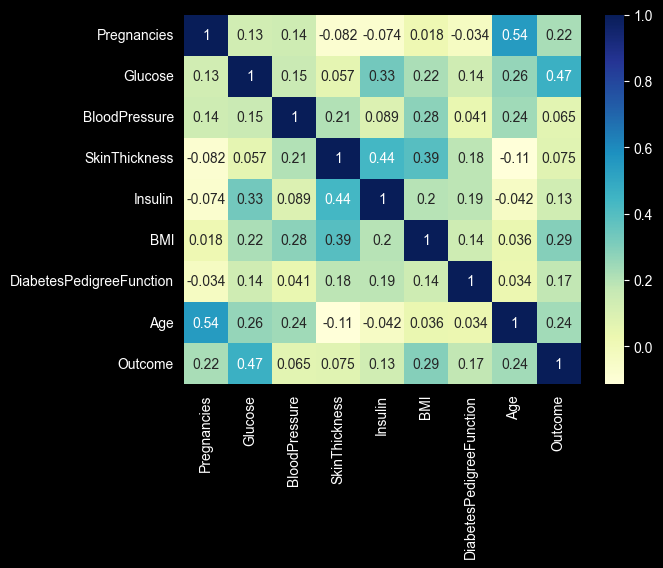

In [17]:
sns.heatmap(df.corr(), annot=True,cmap="YlGnBu")

In [22]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']
print(X)
print(np.unique(y, return_counts=True))

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

#imbalced and balanced

#imbalnced
tree = DecisionTreeClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.78      0.80        99
           1       0.64      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



In [66]:
from sklearn.metrics import f1_score
y_pred_train = tree.predict(X_train)

print(f1_score(y_train, y_pred_train))
print(f1_score(y_test, y_pred))

#overfit

1.0
0.6724137931034483


In [30]:
# balanced

tree_b = DecisionTreeClassifier(class_weight='balanced')
tree_b.fit(X_train, y_train)

y_pred = tree_b.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82        99
           1       0.69      0.67      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



[Text(0.41530311158798283, 0.96875, 'Glucose <= 127.5\ngini = 0.5\nsamples = 614\nvalue = [307.0, 307.0]'),
 Text(0.13479077253218885, 0.90625, 'Age <= 28.5\ngini = 0.43\nsamples = 390\nvalue = [240.394, 109.54]'),
 Text(0.27504694206008584, 0.9375, 'True  '),
 Text(0.05150214592274678, 0.84375, 'BMI <= 30.95\ngini = 0.234\nsamples = 221\nvalue = [156.18, 24.502]'),
 Text(0.017167381974248927, 0.78125, 'DiabetesPedigreeFunction <= 0.672\ngini = 0.03\nsamples = 124\nvalue = [94.167, 1.441]'),
 Text(0.008583690987124463, 0.71875, 'gini = 0.0\nsamples = 108\nvalue = [82.683, 0.0]'),
 Text(0.02575107296137339, 0.71875, 'DiabetesPedigreeFunction <= 0.686\ngini = 0.198\nsamples = 16\nvalue = [11.484, 1.441]'),
 Text(0.017167381974248927, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0.0, 1.441]'),
 Text(0.034334763948497854, 0.65625, 'gini = 0.0\nsamples = 15\nvalue = [11.484, 0.0]'),
 Text(0.08583690987124463, 0.78125, 'BloodPressure <= 37.0\ngini = 0.395\nsamples = 97\nvalue = [62.012, 23.06

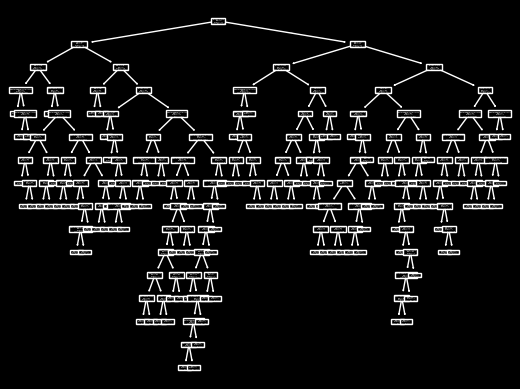

In [34]:
from sklearn.tree import plot_tree
feature_names = df.drop(columns=['Outcome']).columns
plot_tree(tree_b,feature_names=feature_names)

In [35]:
feature_names

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [38]:
print(tree_b.feature_importances_)

[0.03747537 0.29684413 0.13798576 0.07801963 0.05943383 0.15119372
 0.12282557 0.11622199]


In [48]:
f=zip(feature_names, tree_b.feature_importances_)
list(f)

[('Pregnancies', 0.03747537435711543),
 ('Glucose', 0.29684412545250266),
 ('BloodPressure', 0.1379857622449925),
 ('SkinThickness', 0.07801962735132624),
 ('Insulin', 0.059433832566984826),
 ('BMI', 0.1511937233751268),
 ('DiabetesPedigreeFunction', 0.12282556903208301),
 ('Age', 0.11622198561986867)]

In [44]:
a = ['a','b','c']
b = [1,2,3,4]
list(zip(a,b))


[('a', 1), ('b', 2), ('c', 3)]

In [53]:
df=pd.DataFrame(list(zip(feature_names, tree_b.feature_importances_)),columns=['feature','importance'])
df

,feature,importance
0,Pregnancies,0.037475
1,Glucose,0.296844
2,BloodPressure,0.137986
3,SkinThickness,0.078020
4,Insulin,0.059434
5,BMI,0.151194
6,DiabetesPedigreeFunction,0.122826
7,Age,0.116222


In [54]:
df.sort_values(by=['importance'], ascending=False)

,feature,importance
1,Glucose,0.296844
5,BMI,0.151194
2,BloodPressure,0.137986
6,DiabetesPedigreeFunction,0.122826
7,Age,0.116222
3,SkinThickness,0.078020
4,Insulin,0.059434
0,Pregnancies,0.037475


<BarContainer object of 8 artists>

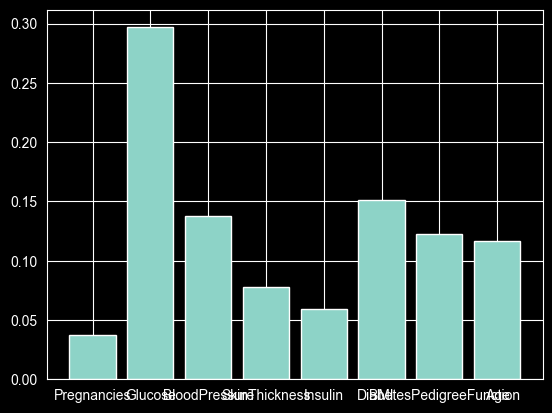

In [55]:
plt.bar(df['feature'], df['importance'])

<BarContainer object of 8 artists>

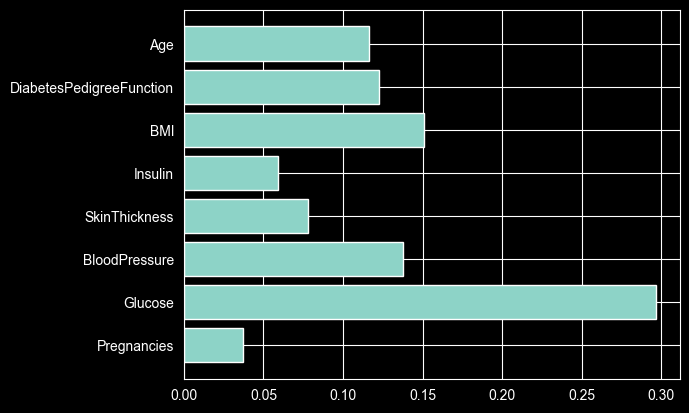

In [56]:
plt.barh(df['feature'], df['importance'])


In [59]:
# now make your model better
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [2,5,10,20,None],
    'min_samples_split': np.arange(2,20,2),
    'min_samples_leaf': np.arange(2,20,2),
}

grid_model = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=params,
    scoring='f1_macro',
    cv=5,
    verbose=10,
    n_jobs=-1
)

grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [2, 5, ...], 'min_samples_leaf': array([ 2, 4..., 14, 16, 18]), 'min_samples_split': array([ 2, 4..., 14, 16, 18])}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [67]:
grid_model.best_params_

{'max_depth': 10, 'min_samples_leaf': 18, 'min_samples_split': 2}

In [68]:
grid_model.best_score_

0.7437606772393448

In [69]:
best_model = grid_model.best_estimator_

In [70]:
y_pred_train = grid_model.predict(X_train)
y_pred_test = grid_model.predict(X_test)


In [73]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       401
           1       0.76      0.77      0.77       213

    accuracy                           0.84       614
   macro avg       0.82      0.82      0.82       614
weighted avg       0.84      0.84      0.84       614



In [75]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154



In [76]:
print(f1_score(y_train, y_pred_train))
print(f1_score(y_test, y_pred_test))

0.765661252900232
0.6779661016949152


In [79]:
# More focused grid - fewer combinations but better pruning
params_focused = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': np.arange(5, 25, 5),
    'min_samples_leaf': np.arange(5, 25, 5),
    'ccp_alpha': [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    'min_impurity_decrease': [0.0, 0.0005, 0.001, 0.005, 0.01]
}

grid_model_focused = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params_focused,
    scoring='f1_macro',
    cv=5,
    verbose=10,
    n_jobs=-1
)

grid_model_focused.fit(X_train, y_train)

print(f"\n=== FOCUSED GRID RESULTS ===")
print(f"Best parameters: {grid_model_focused.best_params_}")
print(f"Best CV score: {grid_model_focused.best_score_:.4f}")

y_pred_train_f = grid_model_focused.predict(X_train)
y_pred_test_f = grid_model_focused.predict(X_test)

print(f"Train F1: {f1_score(y_train, y_pred_train_f):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred_test_f):.4f}")
print(f"Gap: {f1_score(y_train, y_pred_train_f) - f1_score(y_test, y_pred_test_f):.4f}")

Fitting 5 folds for each of 2560 candidates, totalling 12800 fits

=== FOCUSED GRID RESULTS ===
Best parameters: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_impurity_decrease': 0.005, 'min_samples_leaf': 15, 'min_samples_split': 5}
Best CV score: 0.7475
Train F1: 0.7758
Test F1: 0.6557
Gap: 0.1200


In [80]:
print(classification_report(y_test, y_pred_test_f))

              precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154

